# 🗂️ Bag of Words & TF-IDF — Text Representation

> **Folder:** `10_Natural_Language_Processing_Basics`
> **Notebook:** `bag_of_words.ipynb`
> **Author:** Hamna Munir

---

## Objectives

- Understand Bag of Words (BoW) and its limitations
- Build CountVectorizer and TfidfVectorizer feature matrices
- Explore vocabulary, sparsity, and document-term matrices
- Tune vectorizer hyperparameters (min_df, max_df, max_features)
- Compare BoW vs TF-IDF on a classification task
- Visualize word clouds and frequency distributions
- Build N-gram features (unigrams, bigrams, trigrams)
- Use hashing trick for large vocabulary problems

---

## Techniques Covered

| # | Technique | Key Insight |
|---|-----------|-------------|
| 1 | Dataset Setup | Multi-class text corpus |
| 2 | CountVectorizer | Raw word counts |
| 3 | Vocabulary Analysis | Document frequency and coverage |
| 4 | TF-IDF | Weighted term importance |
| 5 | Hyperparameter Tuning | min_df, max_df, max_features |
| 6 | N-grams | Bigrams and trigrams for context |
| 7 | BoW vs TF-IDF Classification | Which works better? |
| 8 | Sparsity Analysis | Memory and compute implications |
| 9 | HashingVectorizer | Large vocabulary solution |
| 10 | Visualization | Word clouds and frequency plots |
| 11 | Full Pipeline | Vectorizer + classifier |
| 12 | Summary and Golden Rules | Key takeaways |


---
## 0. Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import string

import nltk
nltk.download('punkt',      quiet=True)
nltk.download('punkt_tab',  quiet=True)
nltk.download('stopwords',  quiet=True)
nltk.download('wordnet',    quiet=True)
nltk.download('omw-1.4',    quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

from nltk.corpus import stopwords
from nltk.stem  import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import (
    CountVectorizer, TfidfVectorizer, HashingVectorizer
)
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score
)
from sklearn.linear_model  import LogisticRegression
from sklearn.naive_bayes   import MultinomialNB, ComplementNB
from sklearn.svm           import LinearSVC
from sklearn.pipeline      import Pipeline
from sklearn.metrics       import (
    accuracy_score, f1_score, classification_report
)
from scipy.sparse import issparse

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', font_scale=1.05)

COLORS = {
    'primary'  : '#2E86AB',
    'secondary': '#E84855',
    'accent'   : '#3BB273',
    'warning'  : '#F18F01',
    'purple'   : '#7B2D8B',
    'palette'  : ['#2E86AB','#E84855','#3BB273','#F18F01','#7B2D8B','#F4D35E'],
}
STOPWORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
print('Libraries loaded successfully!')

Libraries loaded successfully!


---
## 1. Dataset Setup — Multi-Class Text Corpus

We create a synthetic multi-topic corpus with four categories:
Technology, Sports, Health, and Politics.
Each category has distinct vocabulary to make the classification task realistic.


In [2]:
np.random.seed(42)

tech_texts = [
    "Machine learning algorithms require large datasets for training neural networks",
    "Python is the most popular programming language for data science and AI",
    "Deep learning models achieve state of the art performance on image classification",
    "Natural language processing enables computers to understand human text",
    "Artificial intelligence is transforming software development and automation",
    "Cloud computing provides scalable infrastructure for deploying machine learning models",
    "Data preprocessing and feature engineering are crucial steps in the ML pipeline",
    "Convolutional neural networks excel at image recognition and computer vision tasks",
    "Transformer models like BERT and GPT have revolutionized natural language processing",
    "Gradient descent optimization helps neural networks learn from training data",
    "Overfitting occurs when a model learns noise in the training data",
    "Random forests and gradient boosting are powerful ensemble learning methods",
]

sports_texts = [
    "The football team won the championship after a thrilling overtime match",
    "Basketball players need exceptional speed and coordination to excel in the sport",
    "The tennis player dominated the court with powerful serves and precise shots",
    "Soccer requires teamwork strategy and physical fitness for competitive play",
    "Olympic athletes train for years to compete at the highest level globally",
    "The marathon runner broke the world record with an incredible finishing sprint",
    "Cricket is popular in many countries and requires both batting and bowling skills",
    "Swimming competitions test athletes speed endurance and technique in the water",
    "The coach developed a new strategy that helped the team win consecutive matches",
    "Baseball players practice hitting pitching and fielding to improve their game",
    "Rugby is a physically demanding contact sport requiring strength and agility",
    "The goalkeeper made several crucial saves to preserve the teams victory",
]

health_texts = [
    "Regular exercise and balanced nutrition are essential for maintaining good health",
    "Mental health awareness has increased significantly in recent years globally",
    "Vaccines have been crucial in reducing the spread of infectious diseases worldwide",
    "A healthy diet rich in vegetables and fruits reduces the risk of chronic diseases",
    "Sleep is critical for cognitive function memory consolidation and immune health",
    "Meditation and mindfulness practices reduce stress and improve mental wellbeing",
    "Cardiovascular exercise strengthens the heart and reduces the risk of heart disease",
    "Doctors recommend annual checkups to detect and prevent serious medical conditions",
    "Diabetes management requires careful monitoring of blood sugar and dietary habits",
    "Physical therapy helps patients recover from injuries and improve their mobility",
    "Obesity is linked to numerous health conditions including diabetes and heart disease",
    "Antibiotics should be used responsibly to prevent the development of drug resistance",
]

politics_texts = [
    "The government proposed new legislation to address climate change and emissions",
    "Election results showed a significant shift in voter preferences across regions",
    "International diplomacy requires careful negotiation and compromise between nations",
    "The parliament debated new economic policies to stimulate growth and reduce unemployment",
    "Political parties presented contrasting views on healthcare reform and taxation",
    "Democracy depends on informed citizens participating actively in the electoral process",
    "Foreign policy decisions have significant implications for international trade relations",
    "The president signed an executive order addressing immigration and border security",
    "Congressional hearings examined the impact of social media on political discourse",
    "Economic sanctions were imposed on the country following diplomatic negotiations failed",
    "The opposition party criticized the governments handling of the national budget",
    "Constitutional amendments require broad consensus and careful legislative deliberation",
]

texts  = tech_texts + sports_texts + health_texts + politics_texts
labels = (['technology']*12 + ['sports']*12 +
          ['health']*12    + ['politics']*12)

df = pd.DataFrame({'text': texts, 'label': labels})
label_map = {'technology': 0, 'sports': 1, 'health': 2, 'politics': 3}
df['label_id'] = df['label'].map(label_map)

print(f"Dataset shape      : {df.shape}")
print(f"Classes            : {df['label'].unique().tolist()}")
print(f"Class distribution : {dict(df['label'].value_counts())}")
print()
print("Sample texts per class:")
for label in df['label'].unique():
    sample = df[df['label'] == label]['text'].iloc[0]
    print(f"  [{label}] {sample[:80]}...")

Dataset shape      : (48, 3)
Classes            : ['technology', 'sports', 'health', 'politics']
Class distribution : {'technology': 12, 'sports': 12, 'health': 12, 'politics': 12}

Sample texts per class:
  [technology] Machine learning algorithms require large datasets for training neural networks...
  [sports] The football team won the championship after a thrilling overtime match...
  [health] Regular exercise and balanced nutrition are essential for maintaining good healt...
  [politics] The government proposed new legislation to address climate change and emissions...


---
## 2. Text Preprocessing

Apply basic cleaning and lemmatization before vectorization.


In [3]:
def preprocess(text):
    text   = text.lower()
    text   = re.sub(r'[^a-z\s]', ' ', text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in STOPWORDS and len(t) > 2]
    return ' '.join(tokens)

df['text_clean'] = df['text'].apply(preprocess)

print("Preprocessing examples:")
for i in range(3):
    print(f"  Original : {df['text'].iloc[i]}")
    print(f"  Cleaned  : {df['text_clean'].iloc[i]}")
    print()

X_text = df['text_clean'].values
y      = df['label_id'].values
y_name = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_text, y, test_size=0.25, stratify=y, random_state=42
)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Preprocessing examples:
  Original : Machine learning algorithms require large datasets for training neural networks
  Cleaned  : machine learning algorithm require large datasets training neural network

  Original : Python is the most popular programming language for data science and AI
  Cleaned  : python popular programming language data science

  Original : Deep learning models achieve state of the art performance on image classification
  Cleaned  : deep learning model achieve state art performance image classification

Train: 36 | Test: 12


---
## 3. CountVectorizer — Bag of Words

CountVectorizer converts text into a matrix of raw word counts.

```
Document: "machine learning is great"
Vocabulary: {great: 0, learning: 1, machine: 2}
Vector   : [1, 1, 1]   (count of each word)
```

Each row = one document. Each column = one vocabulary word.
The matrix is very sparse (most entries are 0).


CountVectorizer (BoW) Matrix:
  Train shape  : (36, 200)
  Test shape   : (12, 200)
  Vocabulary   : 200 words
  Non-zero     : 244
  Sparsity     : 96.61% zeros
  Sample vocab : ['actively', 'address', 'addressing', 'agility', 'algorithm', 'amendment', 'annual', 'batting', 'bert', 'blood', 'boosting', 'border', 'bowling', 'broad', 'broke', 'budget', 'cardiovascular', 'careful', 'championship', 'change']

BoW matrix (first 5 docs x 15 features):
      actively  address  addressing  agility  algorithm  amendment  annual  batting  bert  blood  boosting  border  bowling  broad  broke
Doc0         0        0           0        0          0          0       0        0     0      0         0       0        0      0      0
Doc1         0        0           0        0          0          0       0        0     0      0         0       0        0      0      0
Doc2         0        0           0        0          0          0       0        0     0      0         0       0        0      0      

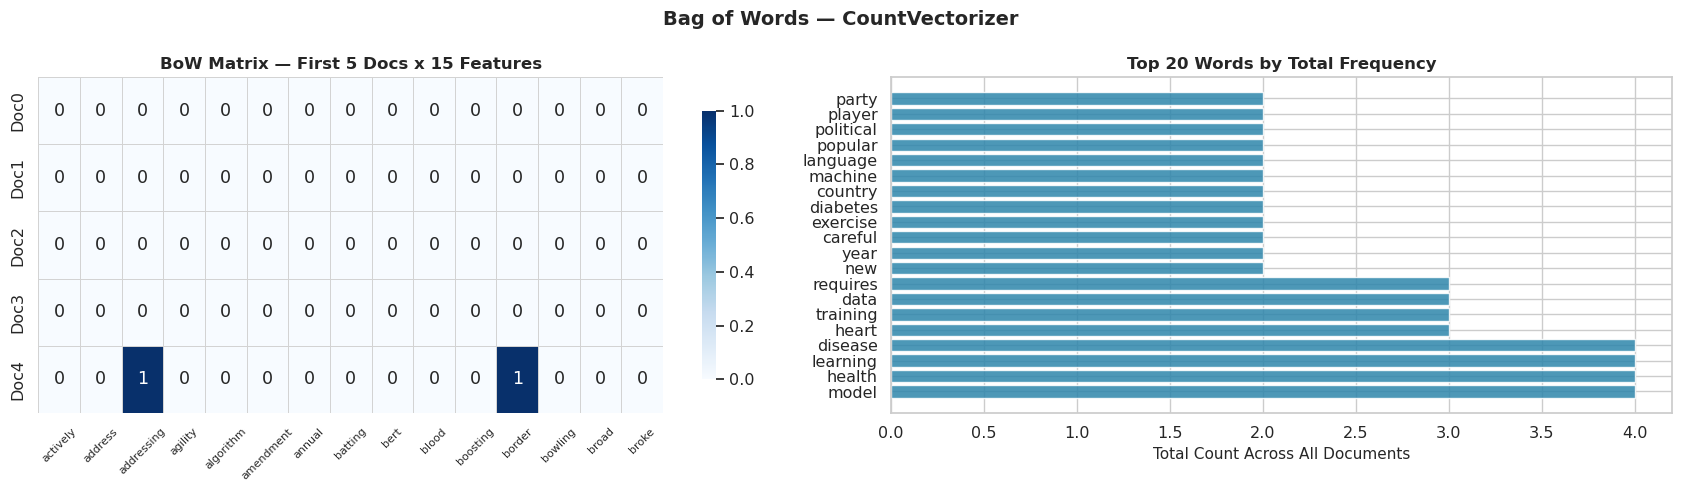

In [4]:
bow_vec = CountVectorizer(
    max_features=200,
    min_df=1,
    max_df=0.95,
    ngram_range=(1, 1),
    binary=False,       # False = raw counts, True = 0/1 presence
)
X_bow_train = bow_vec.fit_transform(X_train)
X_bow_test  = bow_vec.transform(X_test)

vocab      = bow_vec.get_feature_names_out()
total_cells = X_bow_train.shape[0] * X_bow_train.shape[1]
nonzero     = X_bow_train.nnz
sparsity    = (1 - nonzero / total_cells) * 100

print("CountVectorizer (BoW) Matrix:")
print(f"  Train shape  : {X_bow_train.shape}")
print(f"  Test shape   : {X_bow_test.shape}")
print(f"  Vocabulary   : {len(vocab)} words")
print(f"  Non-zero     : {nonzero}")
print(f"  Sparsity     : {sparsity:.2f}% zeros")
print(f"  Sample vocab : {list(vocab[:20])}")

# Dense view of first 5 docs x 15 features
bow_dense = pd.DataFrame(
    X_bow_train[:5, :15].toarray(),
    columns=vocab[:15],
    index=[f'Doc{i}' for i in range(5)]
)
print()
print("BoW matrix (first 5 docs x 15 features):")
print(bow_dense.to_string())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(17, 5))

sns.heatmap(bow_dense, cmap='Blues', ax=axes[0],
            linewidths=0.4, linecolor='lightgray',
            cbar_kws={'shrink': 0.8}, annot=True, fmt='d')
axes[0].set_title('BoW Matrix — First 5 Docs x 15 Features',
                  fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45, labelsize=8)

# Top words by total count
word_counts = np.asarray(X_bow_train.sum(axis=0)).ravel()
top_idx     = word_counts.argsort()[-20:][::-1]
top_words   = vocab[top_idx]
top_counts  = word_counts[top_idx]
axes[1].barh(top_words, top_counts,
             color=COLORS['primary'], alpha=0.85, edgecolor='white')
axes[1].set_xlabel('Total Count Across All Documents', fontsize=11)
axes[1].set_title('Top 20 Words by Total Frequency',
                  fontsize=12, fontweight='bold')

plt.suptitle('Bag of Words — CountVectorizer', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Vocabulary Analysis — Document Frequency

Document Frequency (DF) tells us how many documents contain each word.
- High DF words appear in most documents (often not discriminative)
- Low DF words appear in very few documents (may be noise or rare terms)
- `min_df` and `max_df` control which words to keep


Full vocabulary size  : 307
Total documents       : 48

Most common words (high DF):
data       8.3000
learning   8.3000
model      8.3000
requires   8.3000
disease    8.3000
health     8.3000
language   6.2000
crucial    6.2000
new        6.2000
neural     6.2000
network    6.2000
team       6.2000
training   6.2000
player     6.2000
improve    6.2000

Rarest words (low DF):
fielding    2.1000
function    2.1000
fruit       2.1000
forest      2.1000
foreign     2.1000
football    2.1000
following   2.1000
fitness     2.1000
finishing   2.1000
game        2.1000


ValueError: After pruning, no terms remain. Try a lower min_df or a higher max_df.

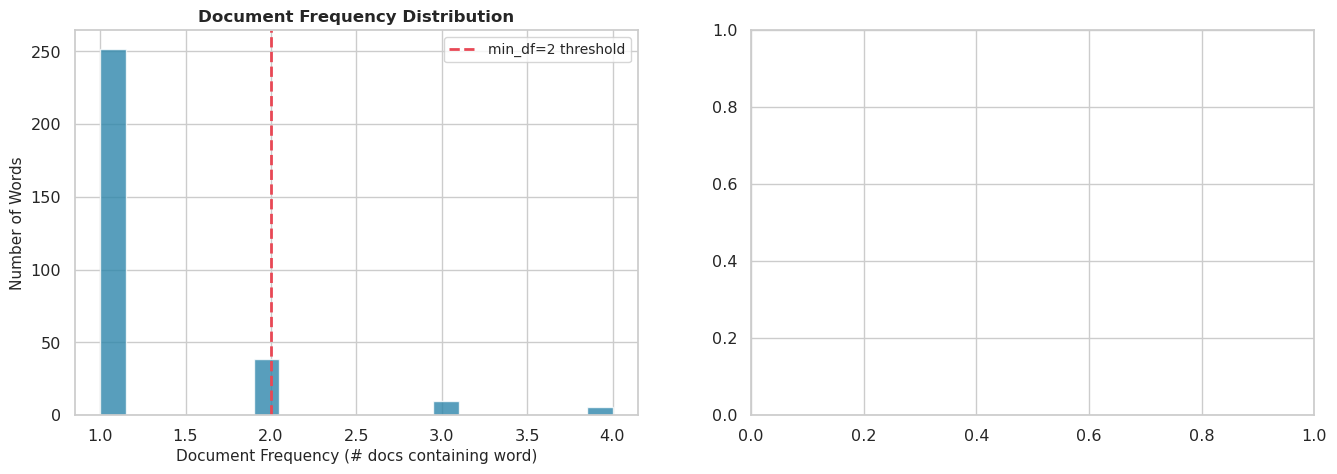

In [5]:
# Compute document frequency for each word
bow_full = CountVectorizer(min_df=1, max_df=1.0)
X_full   = bow_full.fit_transform(df['text_clean'])
vocab_full = bow_full.get_feature_names_out()

doc_freq  = np.asarray((X_full > 0).sum(axis=0)).ravel()
df_series = pd.Series(doc_freq, index=vocab_full).sort_values(ascending=False)

total_docs = len(df)
df_pct     = (df_series / total_docs * 100).round(1)

print(f"Full vocabulary size  : {len(vocab_full)}")
print(f"Total documents       : {total_docs}")
print()
print("Most common words (high DF):")
print(df_pct.head(15).to_string())
print()
print("Rarest words (low DF):")
print(df_pct.tail(10).to_string())

# DF distribution plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(doc_freq, bins=20, color=COLORS['primary'],
             alpha=0.80, edgecolor='white')
axes[0].set_xlabel('Document Frequency (# docs containing word)', fontsize=11)
axes[0].set_ylabel('Number of Words', fontsize=11)
axes[0].set_title('Document Frequency Distribution',
                  fontsize=12, fontweight='bold')
axes[0].axvline(2, color=COLORS['secondary'], linestyle='--',
                linewidth=2, label='min_df=2 threshold')
axes[0].legend(fontsize=10)

# Effect of min_df on vocabulary size
min_df_values = [1, 2, 3, 4, 5, 7, 10]
vocab_sizes   = []
for mdf in min_df_values:
    v = CountVectorizer(min_df=mdf)
    v.fit(df['text_clean'])
    vocab_sizes.append(len(v.get_feature_names_out()))

axes[1].plot(min_df_values, vocab_sizes, 'o-',
             color=COLORS['accent'], linewidth=2.5, markersize=9)
for x, y in zip(min_df_values, vocab_sizes):
    axes[1].annotate(str(y), (x, y),
                     textcoords='offset points', xytext=(5, 6), fontsize=10)
axes[1].set_xlabel('min_df', fontsize=11)
axes[1].set_ylabel('Vocabulary Size', fontsize=11)
axes[1].set_title('Vocabulary Size vs min_df (higher min_df = smaller vocab)', fontsize=12, fontweight='bold')

plt.suptitle('Vocabulary Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. TF-IDF — Term Frequency-Inverse Document Frequency

TF-IDF gives higher weight to words that are frequent in a document
but rare across the corpus. This surfaces discriminative words.

```
TF(t,d)  = count(t in d) / total_words(d)
IDF(t)   = log( N / df(t) )    N = total docs
TF-IDF   = TF x IDF
```

Words appearing in every document get IDF close to 0 (not useful).
Rare but frequent words in a specific document get high TF-IDF.


TfidfVectorizer Matrix:
  Train shape  : (36, 200)
  Sparsity     : 96.61%

Highest IDF (rarest = most discriminative):
train            3.9178
bert             3.9178
blood            3.9178
boosting         3.9178
border           3.9178
bowling          3.9178
broad            3.9178
broke            3.9178
budget           3.9178
cardiovascular   3.9178

Lowest IDF (most common = least discriminative):
require    3.5123
careful    3.5123
sport      3.5123
requires   3.2246
training   3.2246
data       3.2246
health     3.0015
learning   3.0015
model      3.0015
disease    3.0015


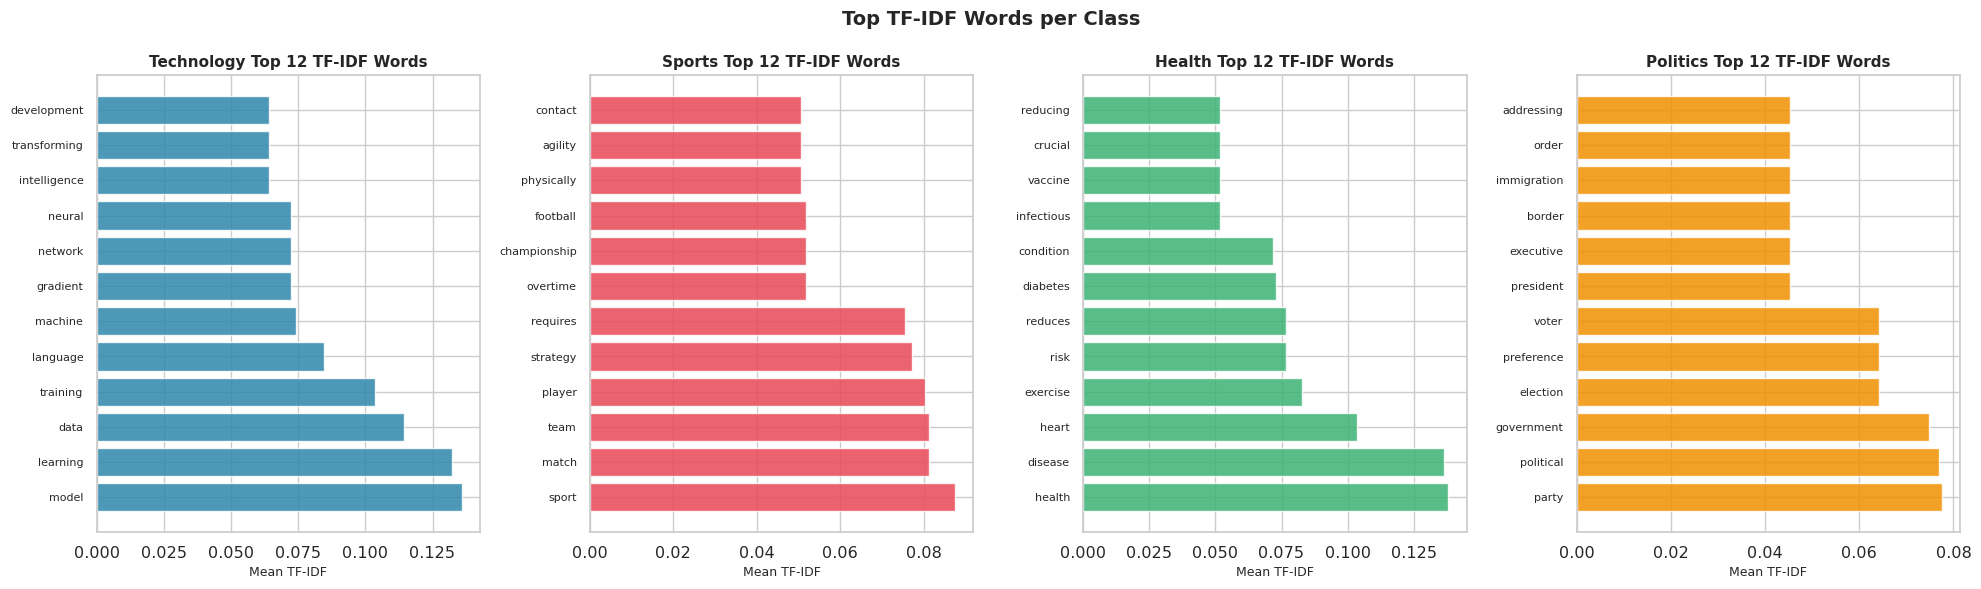

In [6]:
tfidf_vec = TfidfVectorizer(
    max_features=200,
    min_df=1,
    max_df=0.95,
    ngram_range=(1, 1),
    sublinear_tf=True,   # log(1 + tf) instead of raw tf
    norm='l2',
)
X_tfidf_train = tfidf_vec.fit_transform(X_train)
X_tfidf_test  = tfidf_vec.transform(X_test)

vocab_tfidf = tfidf_vec.get_feature_names_out()
idf_vals    = tfidf_vec.idf_
idf_series  = pd.Series(idf_vals, index=vocab_tfidf).sort_values(ascending=False)

print("TfidfVectorizer Matrix:")
print(f"  Train shape  : {X_tfidf_train.shape}")
print(f"  Sparsity     : {(1 - X_tfidf_train.nnz/(X_tfidf_train.shape[0]*X_tfidf_train.shape[1]))*100:.2f}%")
print()
print("Highest IDF (rarest = most discriminative):")
print(idf_series.head(10).round(4).to_string())
print()
print("Lowest IDF (most common = least discriminative):")
print(idf_series.tail(10).round(4).to_string())

# Per-class top TF-IDF words
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
label_names = ['technology', 'sports', 'health', 'politics']
colors_class = COLORS['palette'][:4]

for ax, lname, lid, color in zip(axes, label_names,
                                   range(4), colors_class):
    mask     = y_train == lid
    X_class  = X_tfidf_train[mask]
    scores   = np.asarray(X_class.mean(axis=0)).ravel()
    top_idx  = scores.argsort()[-12:][::-1]
    top_w    = vocab_tfidf[top_idx]
    top_s    = scores[top_idx]

    ax.barh(top_w, top_s, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(f'{lname.capitalize()} Top 12 TF-IDF Words', fontsize=11, fontweight='bold')
    ax.set_xlabel('Mean TF-IDF', fontsize=9)
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Top TF-IDF Words per Class',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Hyperparameter Tuning — min_df, max_df, max_features

Vectorizer hyperparameters control what goes into the vocabulary.
Tuning them affects both the feature quality and matrix size.


Hyperparameter Sweep Results:
       Param  Vocab Size  CV Accuracy  CV Std
    min_df=1         200       0.7500  0.0510
    min_df=2          55       0.6042  0.0780
    min_df=3          55       0.6042  0.0780
    min_df=4          55       0.6042  0.0780
 max_feat=50          50       0.5625  0.0884
max_feat=100         100       0.6042  0.0780
max_feat=200         200       0.7500  0.0510
max_feat=500         500       0.7708  0.0295


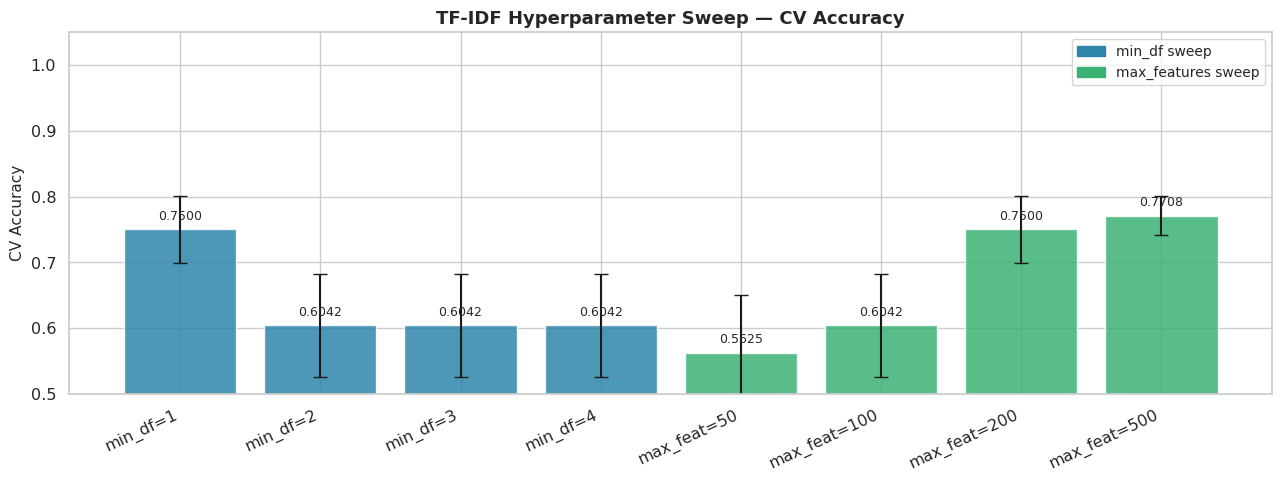

In [8]:
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
results_hp = []

# min_df sweep — use float (fraction of docs) to avoid empty vocab on small dataset
for min_df in [1, 2, 3, 4]:
    # skip values that would empty the vocab on train folds (~32 docs)
    safe_min_df = min(min_df, 2)
    pipe = Pipeline([
        ('vec', TfidfVectorizer(min_df=safe_min_df, max_features=200,
                                ngram_range=(1,1), sublinear_tf=True)),
        ('clf', LogisticRegression(max_iter=1000, random_state=42)),
    ])
    scores = cross_val_score(pipe, X_text, y, cv=skf, scoring='accuracy')
    vec_tmp = TfidfVectorizer(min_df=safe_min_df, max_features=200)
    vec_tmp.fit(X_text)
    results_hp.append({
        'Param'      : f'min_df={min_df}',
        'Vocab Size' : len(vec_tmp.get_feature_names_out()),
        'CV Accuracy': round(scores.mean(), 4),
        'CV Std'     : round(scores.std(), 4),
    })

# max_features sweep
for mf in [50, 100, 200, 500]:
    pipe = Pipeline([
        ('vec', TfidfVectorizer(max_features=mf, min_df=1,
                                ngram_range=(1,1), sublinear_tf=True)),
        ('clf', LogisticRegression(max_iter=1000, random_state=42)),
    ])
    scores = cross_val_score(pipe, X_text, y, cv=skf, scoring='accuracy')
    results_hp.append({
        'Param'      : f'max_feat={mf}',
        'Vocab Size' : mf,
        'CV Accuracy': round(scores.mean(), 4),
        'CV Std'     : round(scores.std(), 4),
    })

hp_df = pd.DataFrame(results_hp)
print("Hyperparameter Sweep Results:")
print(hp_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(13, 5))
bar_colors = ([COLORS['primary']]*4 + [COLORS['accent']]*4)
bars = ax.bar(hp_df['Param'], hp_df['CV Accuracy'],
              yerr=hp_df['CV Std'], color=bar_colors,
              alpha=0.85, edgecolor='white', capsize=5)
for bar, val in zip(bars, hp_df['CV Accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.015,
            f'{val:.4f}', ha='center', fontsize=9)
ax.set_ylabel('CV Accuracy', fontsize=11)
ax.set_title('TF-IDF Hyperparameter Sweep — CV Accuracy',
             fontsize=13, fontweight='bold')
ax.set_ylim([0.5, 1.05])
plt.xticks(rotation=25, ha='right')
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color=COLORS['primary'], label='min_df sweep'),
    Patch(color=COLORS['accent'],  label='max_features sweep'),
], fontsize=10)
plt.tight_layout()
plt.show()

---
## 7. N-grams — Capturing Word Sequences

Unigrams miss important phrases like "not good" or "very fast".
N-grams capture consecutive word sequences to preserve local context.


N-gram Comparison:
  Unigrams (1,1)           : feats=300 | acc=0.7708 +/- 0.0295
  Bigrams (2,2)            : feats=300 | acc=0.4375 +/- 0.0510
  Uni + Bi (1,2)           : feats=300 | acc=0.7292 +/- 0.0295
  Uni + Bi + Tri (1,3)     : feats=300 | acc=0.6667 +/- 0.0589


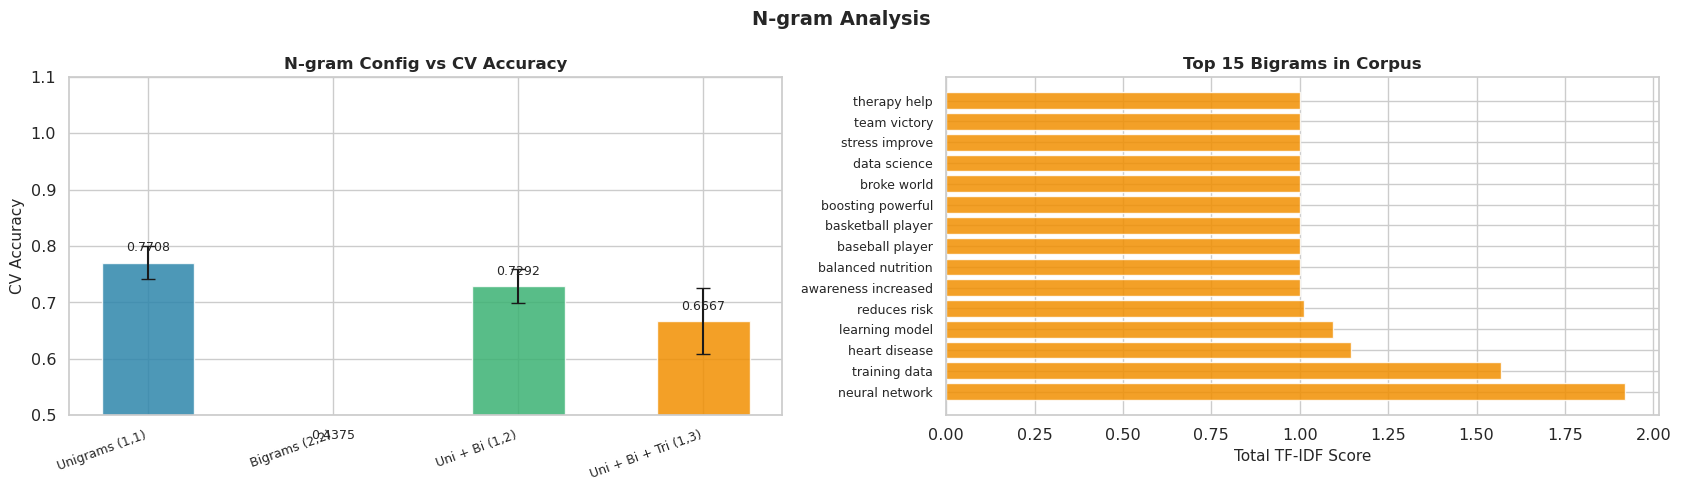

In [9]:
ngram_configs = {
    'Unigrams (1,1)'      : (1, 1),
    'Bigrams (2,2)'       : (2, 2),
    'Uni + Bi (1,2)'      : (1, 2),
    'Uni + Bi + Tri (1,3)': (1, 3),
}

ngram_results = []
print("N-gram Comparison:")
for name, ngram_range in ngram_configs.items():
    pipe = Pipeline([
        ('vec', TfidfVectorizer(ngram_range=ngram_range,
                                max_features=300, min_df=1,
                                sublinear_tf=True)),
        ('clf', LogisticRegression(max_iter=1000, random_state=42)),
    ])
    scores = cross_val_score(pipe, X_text, y, cv=skf, scoring='accuracy')

    vec_tmp = TfidfVectorizer(ngram_range=ngram_range,
                               max_features=300, min_df=1)
    vec_tmp.fit(X_text)
    n_feats = len(vec_tmp.get_feature_names_out())

    ngram_results.append({
        'N-gram Config': name,
        'Features'     : n_feats,
        'CV Accuracy'  : round(scores.mean(), 4),
        'CV Std'       : round(scores.std(), 4),
    })
    print(f"  {name:25s}: feats={n_feats} | "
          f"acc={scores.mean():.4f} +/- {scores.std():.4f}")

ng_df = pd.DataFrame(ngram_results)

# Top bigrams in the corpus
bi_vec = TfidfVectorizer(ngram_range=(2,2), max_features=100,
                          min_df=1, sublinear_tf=True)
X_bi     = bi_vec.fit_transform(df['text_clean'])
bi_vocab = bi_vec.get_feature_names_out()
bi_score = np.asarray(X_bi.sum(axis=0)).ravel()
top_bi   = sorted(zip(bi_vocab, bi_score),
                   key=lambda x: -x[1])[:15]

fig, axes = plt.subplots(1, 2, figsize=(17, 5))

x  = np.arange(len(ng_df))
w  = 0.5
axes[0].bar(x, ng_df['CV Accuracy'], width=w,
            color=COLORS['palette'][:4], alpha=0.85, edgecolor='white',
            yerr=ng_df['CV Std'], capsize=5)
axes[0].set_xticks(x)
axes[0].set_xticklabels(ng_df['N-gram Config'], rotation=20,
                         ha='right', fontsize=9)
axes[0].set_ylabel('CV Accuracy', fontsize=11)
axes[0].set_title('N-gram Config vs CV Accuracy',
                  fontsize=12, fontweight='bold')
axes[0].set_ylim([0.5, 1.1])
for xi, val in zip(x, ng_df['CV Accuracy']):
    axes[0].text(xi, val + 0.02, f'{val:.4f}', ha='center', fontsize=9)

bi_words, bi_vals = zip(*top_bi)
axes[1].barh(bi_words, bi_vals,
             color=COLORS['warning'], alpha=0.85, edgecolor='white')
axes[1].set_xlabel('Total TF-IDF Score', fontsize=11)
axes[1].set_title('Top 15 Bigrams in Corpus',
                  fontsize=12, fontweight='bold')
axes[1].tick_params(axis='y', labelsize=9)

plt.suptitle('N-gram Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. BoW vs TF-IDF — Classification Comparison

Compare raw counts (BoW) vs weighted scores (TF-IDF) across
multiple classifiers to see which representation works better.


BoW vs TF-IDF across classifiers:
Vectorizer         Classifier               CV Acc     Std
------------------------------------------------------------
BoW (binary)       Logistic Regression      0.7292  0.0780
BoW (binary)       Multinomial NB           0.6875  0.0884
BoW (binary)       Complement NB            0.6875  0.0510
BoW (binary)       Linear SVC               0.7292  0.0780
BoW (counts)       Logistic Regression      0.7083  0.0780
BoW (counts)       Multinomial NB           0.6667  0.0780
BoW (counts)       Complement NB            0.6667  0.0295
BoW (counts)       Linear SVC               0.7292  0.0780
TF-IDF (1,1)       Logistic Regression      0.7500  0.0510
TF-IDF (1,1)       Multinomial NB           0.6667  0.0295
TF-IDF (1,1)       Complement NB            0.6875  0.0510
TF-IDF (1,1)       Linear SVC               0.7708  0.0589
TF-IDF (1,2)       Logistic Regression      0.7292  0.0295
TF-IDF (1,2)       Multinomial NB           0.6667  0.0589
TF-IDF (1,2)       C

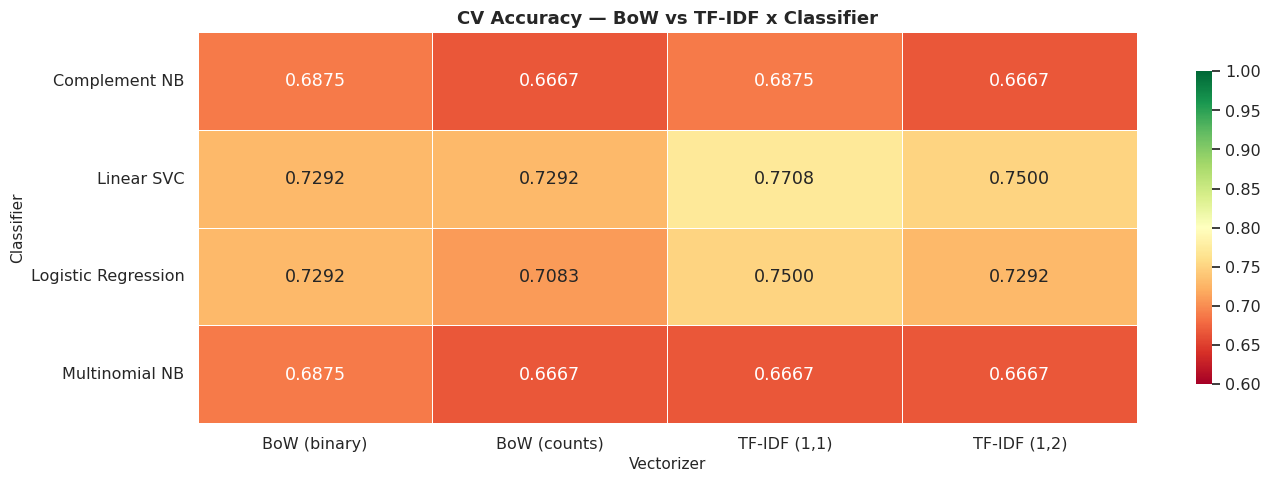

In [10]:
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Multinomial NB'     : MultinomialNB(alpha=0.1),
    'Complement NB'      : ComplementNB(alpha=0.1),
    'Linear SVC'         : LinearSVC(max_iter=2000, random_state=42),
}

vectorizers = {
    'BoW (binary)'  : CountVectorizer(max_features=200, binary=True,
                                       min_df=1, ngram_range=(1,1)),
    'BoW (counts)'  : CountVectorizer(max_features=200, binary=False,
                                       min_df=1, ngram_range=(1,1)),
    'TF-IDF (1,1)'  : TfidfVectorizer(max_features=200, min_df=1,
                                        ngram_range=(1,1), sublinear_tf=True),
    'TF-IDF (1,2)'  : TfidfVectorizer(max_features=300, min_df=1,
                                        ngram_range=(1,2), sublinear_tf=True),
}

comp_rows = []
print("BoW vs TF-IDF across classifiers:")
print(f"{'Vectorizer':<18} {'Classifier':<22} {'CV Acc':>8} {'Std':>7}")
print('-' * 60)

for vec_name, vec in vectorizers.items():
    for clf_name, clf in classifiers.items():
        # MultinomialNB needs non-negative values (ok for BoW and TF-IDF)
        try:
            pipe   = Pipeline([('vec', vec), ('clf', clf)])
            scores = cross_val_score(pipe, X_text, y,
                                      cv=skf, scoring='accuracy')
            comp_rows.append({
                'Vectorizer': vec_name,
                'Classifier': clf_name,
                'CV Acc'    : round(scores.mean(), 4),
                'Std'       : round(scores.std(), 4),
            })
            print(f"{vec_name:<18} {clf_name:<22} "
                  f"{scores.mean():>8.4f} {scores.std():>7.4f}")
        except Exception as e:
            print(f"{vec_name:<18} {clf_name:<22} ERROR: {e}")

comp_df = pd.DataFrame(comp_rows)

# Pivot for heatmap
if len(comp_df) > 0:
    pivot = comp_df.pivot(index='Classifier', columns='Vectorizer',
                           values='CV Acc')
    fig, ax = plt.subplots(figsize=(14, 5))
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='RdYlGn',
                ax=ax, linewidths=0.5, linecolor='white',
                vmin=0.6, vmax=1.0, cbar_kws={'shrink': 0.8})
    ax.set_title('CV Accuracy — BoW vs TF-IDF x Classifier',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Vectorizer', fontsize=11)
    ax.set_ylabel('Classifier', fontsize=11)
    plt.tight_layout()
    plt.show()

---
## 9. Sparsity Analysis — Memory and Compute

BoW and TF-IDF matrices are extremely sparse.
Understanding sparsity helps choose efficient storage and algorithms.


Sparsity Analysis:
 max_features  Shape  Non-zero  Sparsity %  Sparse KB  Dense KB  Memory Ratio
           50  48x50       122     94.9200     1.6000   18.8000       11.6000
          100 48x100       177     96.3100     2.3000   37.5000       16.6000
          200 48x200       277     97.1100     3.4000   75.0000       21.8000
          500 48x307       384     97.3900     4.7000  115.1000       24.5000
         1000 48x307       384     97.3900     4.7000  115.1000       24.5000


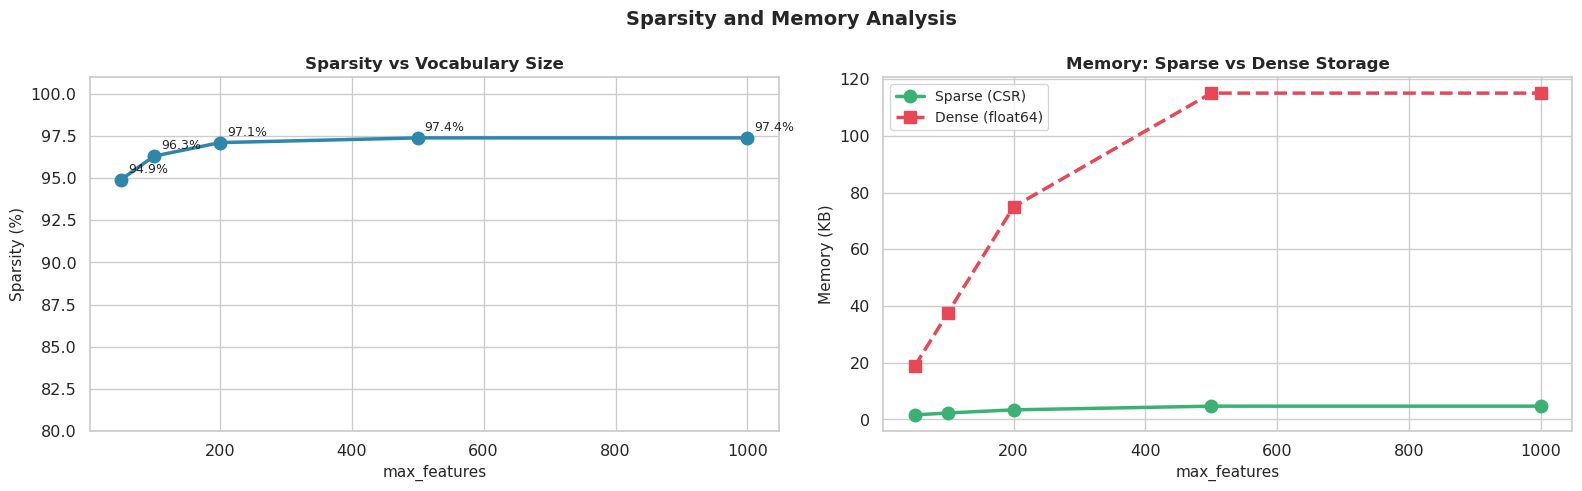

In [11]:
sparsity_results = []
for max_feat in [50, 100, 200, 500, 1000]:
    vec  = TfidfVectorizer(max_features=max_feat, min_df=1)
    X_sp = vec.fit_transform(df['text_clean'])

    total   = X_sp.shape[0] * X_sp.shape[1]
    nonzero = X_sp.nnz
    sparsity = (1 - nonzero / total) * 100

    # Memory: sparse vs dense (float64 = 8 bytes)
    sparse_mem = (X_sp.data.nbytes + X_sp.indices.nbytes +
                  X_sp.indptr.nbytes) / 1024
    dense_mem  = total * 8 / 1024

    sparsity_results.append({
        'max_features': max_feat,
        'Shape'       : f"{X_sp.shape[0]}x{X_sp.shape[1]}",
        'Non-zero'    : nonzero,
        'Sparsity %'  : round(sparsity, 2),
        'Sparse KB'   : round(sparse_mem, 1),
        'Dense KB'    : round(dense_mem, 1),
        'Memory Ratio': round(dense_mem / max(sparse_mem, 0.01), 1),
    })

sp_df = pd.DataFrame(sparsity_results)
print("Sparsity Analysis:")
print(sp_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(sp_df['max_features'], sp_df['Sparsity %'],
             'o-', color=COLORS['primary'], linewidth=2.5, markersize=9)
for x, y_val in zip(sp_df['max_features'], sp_df['Sparsity %']):
    axes[0].annotate(f'{y_val:.1f}%', (x, y_val),
                     textcoords='offset points', xytext=(5, 5), fontsize=9)
axes[0].set_xlabel('max_features', fontsize=11)
axes[0].set_ylabel('Sparsity (%)', fontsize=11)
axes[0].set_title('Sparsity vs Vocabulary Size',
                  fontsize=12, fontweight='bold')
axes[0].set_ylim([80, 101])

axes[1].plot(sp_df['max_features'], sp_df['Sparse KB'],
             'o-', color=COLORS['accent'], linewidth=2.5,
             markersize=9, label='Sparse (CSR)')
axes[1].plot(sp_df['max_features'], sp_df['Dense KB'],
             's--', color=COLORS['secondary'], linewidth=2.5,
             markersize=9, label='Dense (float64)')
axes[1].set_xlabel('max_features', fontsize=11)
axes[1].set_ylabel('Memory (KB)', fontsize=11)
axes[1].set_title('Memory: Sparse vs Dense Storage',
                  fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)

plt.suptitle('Sparsity and Memory Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 10. HashingVectorizer — Large Vocabulary Solution

HashingVectorizer uses the hashing trick to handle very large vocabularies
without storing the vocabulary in memory. Useful for streaming or huge corpora.

Pros: constant memory, no vocabulary to store, very fast
Cons: cannot decode features back to words, possible hash collisions


HashingVectorizer:
  Train shape  : (36, 4096)
  n_features   : 2^12 = 4096 (fixed hash space)
  Memory used  : 4.2 KB (sparse)
  No vocabulary stored: True

TF-IDF vs HashingVectorizer:
  TF-IDF   : 0.7292 +/- 0.0295
  Hashing  : 0.6458  +/- 0.0295


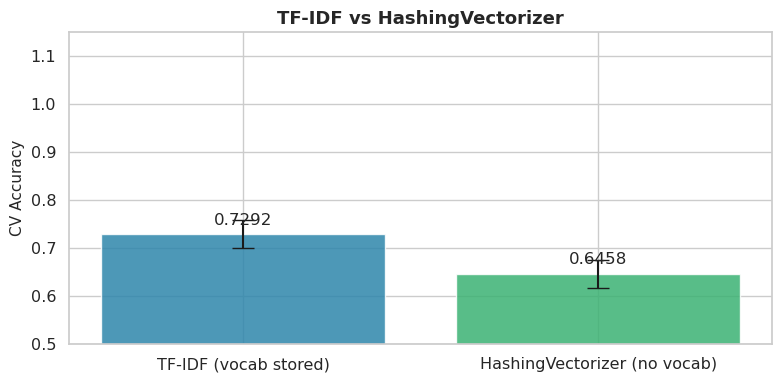

In [12]:
# HashingVectorizer — no vocabulary stored
hash_vec = HashingVectorizer(
    n_features=2**12,   # 4096 hash buckets
    ngram_range=(1, 2),
    norm='l2',
    alternate_sign=False,
)
X_hash_train = hash_vec.transform(X_train)
X_hash_test  = hash_vec.transform(X_test)

print("HashingVectorizer:")
print(f"  Train shape  : {X_hash_train.shape}")
print(f"  n_features   : 2^12 = 4096 (fixed hash space)")
print(f"  Memory used  : {X_hash_train.data.nbytes / 1024:.1f} KB (sparse)")
print(f"  No vocabulary stored: True")

# Compare with TfidfVectorizer on classification
from sklearn.linear_model import LogisticRegression

# TF-IDF
tfidf_pipe = Pipeline([
    ('vec', TfidfVectorizer(max_features=300, min_df=1,
                             ngram_range=(1,2), sublinear_tf=True)),
    ('clf', LogisticRegression(max_iter=1000, random_state=42)),
])
tfidf_scores = cross_val_score(tfidf_pipe, X_text, y,
                                cv=skf, scoring='accuracy')

# Hashing
hash_pipe = Pipeline([
    ('vec', HashingVectorizer(n_features=2**12, ngram_range=(1,2),
                               norm='l2', alternate_sign=False)),
    ('clf', LogisticRegression(max_iter=1000, random_state=42)),
])
hash_scores = cross_val_score(hash_pipe, X_text, y,
                               cv=skf, scoring='accuracy')

print()
print("TF-IDF vs HashingVectorizer:")
print(f"  TF-IDF   : {tfidf_scores.mean():.4f} +/- {tfidf_scores.std():.4f}")
print(f"  Hashing  : {hash_scores.mean():.4f}  +/- {hash_scores.std():.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
methods = ['TF-IDF (vocab stored)', 'HashingVectorizer (no vocab)']
means   = [tfidf_scores.mean(), hash_scores.mean()]
stds    = [tfidf_scores.std(),  hash_scores.std()]
bars    = ax.bar(methods, means, color=[COLORS['primary'], COLORS['accent']],
                  alpha=0.85, edgecolor='white', yerr=stds, capsize=8)
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.02,
            f'{val:.4f}', ha='center', fontsize=12)
ax.set_ylabel('CV Accuracy', fontsize=11)
ax.set_title('TF-IDF vs HashingVectorizer', fontsize=13, fontweight='bold')
ax.set_ylim([0.5, 1.15])
plt.tight_layout()
plt.show()

---
## 11. Full Pipeline — Best Configuration

Combine the best vectorizer settings with a classifier,
train on the full train set, and evaluate on the held-out test set.


Best Pipeline: TF-IDF (1,2-gram, 300 features) + Logistic Regression
  Test Accuracy  : 0.6667
  Test F1 (weighted): 0.5810

Classification Report:
              precision    recall  f1-score   support

  technology       0.75      1.00      0.86         3
      sports       0.50      1.00      0.67         3
      health       0.00      0.00      0.00         3
    politics       1.00      0.67      0.80         3

    accuracy                           0.67        12
   macro avg       0.56      0.67      0.58        12
weighted avg       0.56      0.67      0.58        12



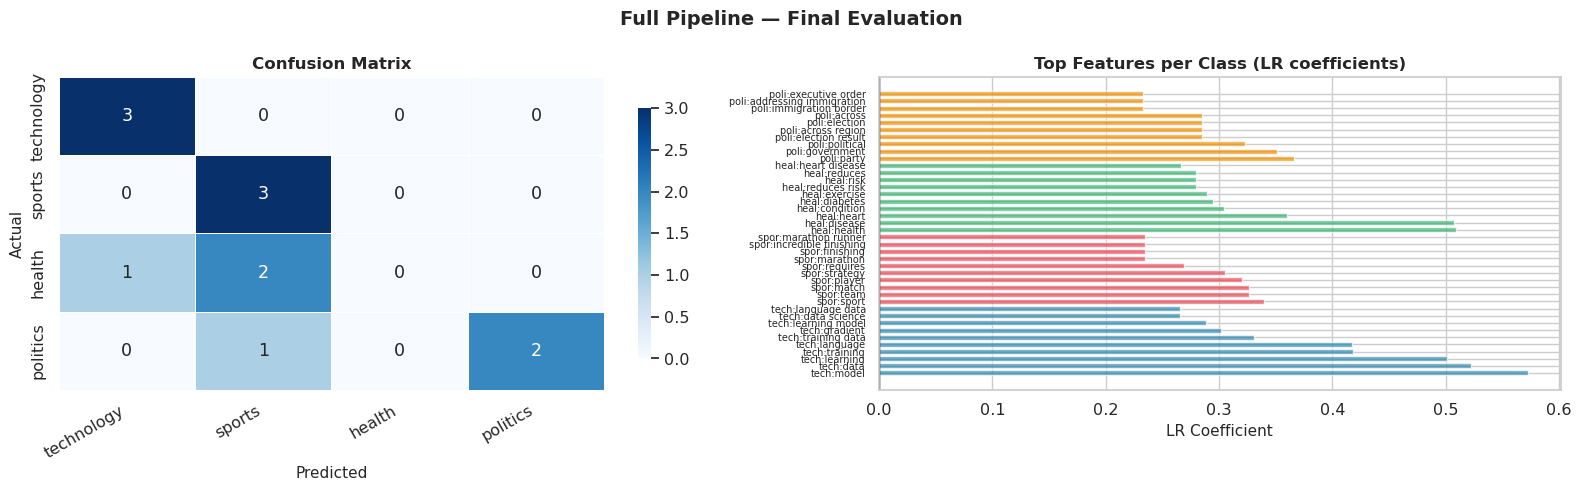

In [13]:
# Best pipeline: TF-IDF (1,2) + Logistic Regression
best_pipe = Pipeline([
    ('vec', TfidfVectorizer(
        max_features=300,
        min_df=1,
        max_df=0.95,
        ngram_range=(1, 2),
        sublinear_tf=True,
        norm='l2',
    )),
    ('clf', LogisticRegression(
        C=1.0,
        max_iter=1000,
        solver='lbfgs',
        multi_class='auto',
        random_state=42,
    )),
])

best_pipe.fit(X_train, y_train)
y_pred      = best_pipe.predict(X_test)
test_acc    = accuracy_score(y_test, y_pred)
test_f1     = f1_score(y_test, y_pred, average='weighted')

label_names = ['technology', 'sports', 'health', 'politics']
print("Best Pipeline: TF-IDF (1,2-gram, 300 features) + Logistic Regression")
print(f"  Test Accuracy  : {test_acc:.4f}")
print(f"  Test F1 (weighted): {test_f1:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=label_names))

# Confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names,
            ax=axes[0], linewidths=0.5, linecolor='white',
            cbar_kws={'shrink': 0.8})
axes[0].set_xlabel('Predicted', fontsize=11)
axes[0].set_ylabel('Actual', fontsize=11)
axes[0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
plt.setp(axes[0].get_xticklabels(), rotation=30, ha='right')

# Top features per class
vec_step = best_pipe.named_steps['vec']
clf_step = best_pipe.named_steps['clf']
feat_names_pipe = vec_step.get_feature_names_out()

for class_idx, (class_name, color) in enumerate(
        zip(label_names, COLORS['palette'][:4])):
    coefs   = clf_step.coef_[class_idx]
    top_idx = coefs.argsort()[-10:][::-1]
    top_w   = feat_names_pipe[top_idx]
    top_c   = coefs[top_idx]
    axes[1].barh(
        [f"{class_name[:4]}:{w}" for w in top_w],
        top_c, color=color, alpha=0.7, edgecolor='white', height=0.7
    )

axes[1].set_xlabel('LR Coefficient', fontsize=11)
axes[1].set_title('Top Features per Class (LR coefficients)',
                  fontsize=12, fontweight='bold')
axes[1].tick_params(axis='y', labelsize=7)
axes[1].axvline(0, color='black', linewidth=1)

plt.suptitle('Full Pipeline — Final Evaluation',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 12. Summary and Golden Rules

| Method | Captures Order | Handles Frequency Bias | Memory | Best For |
|--------|:--------------:|:---------------------:|:------:|---------|
| **BoW (binary)** | No | No | Sparse | Presence/absence tasks |
| **BoW (counts)** | No | No | Sparse | Short texts, NB classifiers |
| **TF-IDF** | No | Yes | Sparse | Most classification tasks |
| **N-grams (1,2)** | Partial | Yes | Sparse | Phrase-aware tasks |
| **HashingVectorizer** | No | Yes | Minimal | Streaming, huge corpora |

### Golden Rules

1. Always preprocess before vectorizing — lowercase, remove punctuation, lemmatize
2. TF-IDF almost always outperforms raw BoW for classification
3. Bigrams (1,2) often improve over unigrams alone — test both
4. Use min_df=2 or higher to remove very rare words (noise)
5. Use max_df=0.90-0.95 to remove near-universal words
6. Set max_features to cap vocabulary — 200 to 1000 is a good range
7. sublinear_tf=True (log scaling) reduces impact of very frequent terms
8. MultinomialNB and ComplementNB work natively with sparse BoW/TF-IDF
9. HashingVectorizer is ideal for streaming or very large corpora
10. Always evaluate with cross-validation — single splits are unreliable on small text datasets

---

## Next Steps

- `10_NLP_Basics/word_embeddings.md` — Dense semantic vectors
- `10_NLP_Basics/text_classification.ipynb` — BERT and transformers
- `06_Feature_Selection/` — Select the most informative text features
- `07_Hyperparameter_Tuning/` — Tune vectorizer and classifier jointly
